# (노트) Lasso, Ridge, Elastic-net 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

### About this doc 

`-` 2021년 1학기 전북대학교 데이터과학 강의노트

### 예제1

#### Data: 

In [3]:
import rpy2
%load_ext rpy2.ipython

In [5]:
%%R
set.seed(9999)
n<-20000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
teps<-toeic + rnorm(n,sd=0.01)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

#### Analysis: 

#### [데이터정리]

In [6]:
%%R
X<-cbind(toeic,teps,gpa)
y<-sal 

In [7]:
%%R
print(head(X))

     toeic     teps gpa
[1,]   837 837.0066 3.1
[2,]   817 816.9809 3.6
[3,]   790 789.9939 3.5
[4,]   688 687.9981 3.6
[5,]   982 981.9988 2.9
[6,]   823 823.0172 3.9


In [8]:
%R -o X,y

In [9]:
X,y

(array([[837.        , 837.00659926,   3.1       ],
        [817.        , 816.98090417,   3.6       ],
        [790.        , 789.99388281,   3.5       ],
        ...,
        [828.        , 828.00137839,   3.6       ],
        [782.        , 782.00527482,   3.7       ],
        [822.        , 822.01226229,   2.7       ]]),
 array([5668., 6168., 5966., ..., 6075., 6554., 5893.]))

### [풀이1] Ridge: 해석적풀이

In [10]:
import numpy as np

In [11]:
λ=1
λI=np.diag([λ]*3)
λI

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [12]:
bhat_ridge=np.linalg.inv(X.T@ X + λI) @ X.T @y 

In [13]:
bhat_ridge

array([-79.208969  ,  84.21375457, 600.83093632])

### [풀이2] Ridge: `sklearn`패키지 활용

In [14]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0) # alpha는 lambda값임 
rlst=ridge.fit(X,y)

In [15]:
rlst.coef_

array([-79.427324  ,  84.45760997, 609.14106189])

### [풀이3] Lasso: `sklearn` 패키지 활용

In [16]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0) # alpha는 lambda값임 
rlst=lasso.fit(X,y)
rlst.coef_

array([5.02994425e+00, 5.06370365e-06, 5.98333362e+02])

--> ${\tt teps}$에 해당하는 계수가 0이므로 Lasso에 의해 변수선택이 잘 되었음을 알 수 있다. 

### [풀이4] Ridge: `glmnet`패키지 활용

- 변수 표준화를 해줌
- 최적의 $\lambda$값을 찾아줌

R[write to console]: Loading required package: Matrix

R[write to console]: Loaded glmnet 4.1



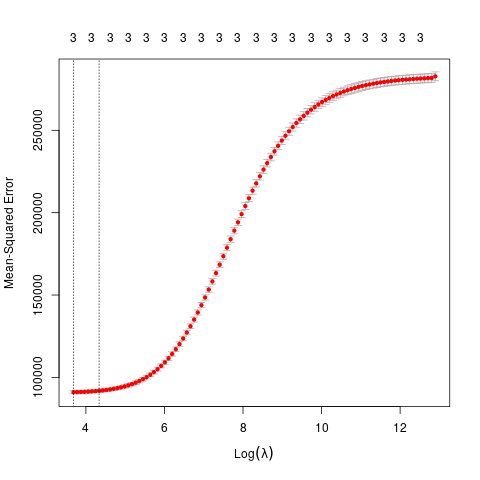

In [17]:
%%R 
library(glmnet)
cvfit_ridge<- cv.glmnet(X,y,alpha=0) ## alpha=0 : Ridge
plot(cvfit_ridge)

`cv.glmnet(X,y,alpha=0)`에서 
- `alpha=0`: Ridge
- `alpha=1`: Lasso 
- `alpha` $\in (0,1)`: Elastic-net 

왼쪽점선: 최적값 (교차검증오차의 최소값)

오른쪽점선: 최적이랑 비슷하면서 간단한 모형을 만드는 $\lambda$

In [18]:
%%R
print(log(cvfit_ridge$lambda.min))
print(log(cvfit_ridge$lambda.1se))

[1] 3.68502
[1] 4.336256


따라서 람다는 

In [19]:
%%R
print(cvfit_ridge$lambda.min)
print(cvfit_ridge$lambda.1se)

[1] 39.84592
[1] 76.42089


In [20]:
%%R 
cvfit_ridge


Call:  cv.glmnet(x = X, y = y, alpha = 0) 

Measure: Mean-Squared Error 

    Lambda Index Measure    SE Nonzero
min  39.85   100   91006 884.9       3
1se  76.42    93   91881 928.4       3


In [21]:
%%R 
print(coef(cvfit_ridge,s='lambda.min'))
print(coef(cvfit_ridge,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 235.939274
toeic         2.434812
teps          2.413922
gpa         566.809663
4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 472.998392
toeic         2.350221
teps          2.342250
gpa         532.575101


두 모형이 모두 그럴 듯 함.

(i) 토익, 텝스에 대응하는 계수합이 5이어야 하며 

(ii) 토익, 텝스의 계수값이 거의 비슷해야하는데 

이론적인 탐구내용과 일치함. 

[풀이5] Lasso: `glmnet`을 활용 

In [22]:
%%R 
library(glmnet)
cvfit_lasso<- cv.glmnet(X,y,alpha=1) 
## alpha=1 : Lasso
cvfit_lasso


Call:  cv.glmnet(x = X, y = y, alpha = 1) 

Measure: Mean-Squared Error 

    Lambda Index Measure   SE Nonzero
min  1.983    58   90649 1314       3
1se 24.449    31   91842 1346       3


In [23]:
%%R 
print(coef(cvfit_lasso,s='lambda.min'))
print(coef(cvfit_lasso,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept) -7.508038e+00
toeic        5.004742e+00
teps         4.435535e-04
gpa          6.028313e+02
4 x 1 sparse Matrix of class "dgCMatrix"
                       1
(Intercept) 4.692355e+02
toeic       4.720722e+00
teps        2.299091e-04
gpa         5.275315e+02


### 예제 2

자료: 야구선수

In [24]:
%%R 
# install.packages("ISLR")
library(ISLR)
head(Hitters)

R[write to console]: Error in library(ISLR) : there is no package called ‘ISLR’




Error in library(ISLR) : there is no package called ‘ISLR’


목표: $y$를 Salary로 설정하고 나머지를 $X$로 설정하고 회귀분석 한다. 

분석: 

단계1: missing이 보이므로 제거

In [25]:
%%R 
Hitters<-na.omit(Hitters)
head(Hitters)

R[write to console]: Error in na.omit(Hitters) : object 'Hitters' not found




Error in na.omit(Hitters) : object 'Hitters' not found


단계2: $X$, $y$ 분리

In [26]:
%%R
y<- Hitters$Salary
X<- model.matrix(Salary~., Hitters)

R[write to console]: Error in withVisible({ : object 'Hitters' not found




Error in withVisible({ : object 'Hitters' not found


단계3: (1) Lasso

In [27]:
%%R 
library(glmnet)
cvfit_lasso<-cv.glmnet(X,y,alpha=1)
print(coef(cvfit_lasso,s='lambda.min'))
print(coef(cvfit_lasso,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept) -7.508038e+00
toeic        5.004742e+00
teps         4.435535e-04
gpa          6.028313e+02
4 x 1 sparse Matrix of class "dgCMatrix"
                       1
(Intercept) 3.811478e+02
toeic       4.773224e+00
teps        2.456265e-04
gpa         5.414446e+02


단계3: (2) Ridge

In [28]:
%%R 
cvfit_ridge<-cv.glmnet(X,y,alpha=0)
print(coef(cvfit_ridge,s='lambda.min'))
print(coef(cvfit_ridge,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 235.939274
toeic         2.434812
teps          2.413922
gpa         566.809663
4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 430.593934
toeic         2.365950
teps          2.354866
gpa         538.614318


단계3: (3) 일레스틱넷

In [29]:
%%R 
cvfit_elastic<-cv.glmnet(X,y,alpha=0.3)
print(coef(cvfit_elastic,s='lambda.min'))
print(coef(cvfit_elastic,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept)  -5.726693
toeic         2.541064
teps          2.462546
gpa         602.660376
4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 425.606904
toeic         2.383025
teps          2.353837
gpa         536.593202
